<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import pandas as pd
from sklearn.metrics import classification_report

In [ ]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/train.csv")

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [10]:
target_col = 'Exited'
input_cols = [col for col in raw_df.columns if col not in ['id', 'CustomerId', 'Surname', target_col]]

# Split the raw dataframe into training and validation dataframes
train_df, val_df = split_train_val(raw_df, target_col)

# Separate inputs and targets for both training and validation sets
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

# Identify categorical columns (object type columns are typically categorical)
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

# Convert identified categorical columns to 'category' type in both inputs sets
for col in categorical_cols:
    train_inputs[col] = train_inputs[col].astype('category')
    val_inputs[col] = val_inputs[col].astype('category')

print(f"Categorical columns identified: {categorical_cols}")
print("Train inputs dtypes after conversion:")
print(train_inputs[categorical_cols].dtypes)
print("\nValidation inputs dtypes after conversion:")
print(val_inputs[categorical_cols].dtypes)

Categorical columns identified: ['Geography', 'Gender']
Train inputs dtypes after conversion:
Geography    category
Gender       category
dtype: object

Validation inputs dtypes after conversion:
Geography    category
Gender       category
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [15]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import numpy as np

# Initialize XGBoostClassifier with specified parameters
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    enable_categorical=True,
    n_estimators=10,
    learning_rate=0.1,
    max_depth =3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    missing=np.nan,
    device= 'cuda'
)

# Train model
xgb_clf.fit(train_inputs, train_targets)
# Predict probabilities
train_preds_proba = xgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_proba = xgb_clf.predict_proba(val_inputs)[:, 1]
# Calculate AUROC scores
train_auc = roc_auc_score(train_targets, train_preds_proba)
val_auc = roc_auc_score(val_targets, val_preds_proba)

print(f"\nTrain AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")


Train AUROC: 0.9260
Validation AUROC: 0.9254


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:30:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Висновок: маємо досить високий TrainAUROC 0.9260 та  Val AUROC 0.9254,також невелику різницю між ними, що може свідчити що немає явних ознак перенавчання або недонавчання. У попередньому завданні дерева показали Train AUROC: 0.9257, Val AUROC: 0.9219, тож XGBoost показав незначне покращення

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [16]:
!pip install hyperopt

In [18]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score

In [30]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np

def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )

    pred_proba = clf.predict_proba(val_inputs)[:, 1]
    auc_score = roc_auc_score(val_targets, pred_proba)

    return {'loss': -auc_score, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

final_clf.fit(train_inputs, train_targets)

# Evaluate with AUROC for consistency
final_train_preds_proba = final_clf.predict_proba(train_inputs)[:, 1]
final_val_preds_proba = final_clf.predict_proba(val_inputs)[:, 1]

final_train_auc = roc_auc_score(train_targets, final_train_preds_proba)
final_val_auc = roc_auc_score(val_targets, final_val_preds_proba)

print(f"Train AUROC з найкращими гіперпараметрами: {final_train_auc:.4f}")
print(f"Validation AUROC з найкращими гіперпараметрами: {final_val_auc:.4f}")

# Get predicted classes for the validation set
final_val_preds = final_clf.predict(val_inputs)

# Print classification report for the validation set
print("\nClassification Report (Validation Set - Tuned XGBoost):")
print(classification_report(val_targets, final_val_preds))

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 1/20 [00:01<00:31,  1.66s/trial, best loss: -0.9144721860209891]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 10%|█         | 2/20 [00:03<00:33,  1.86s/trial, best loss: -0.9190808697441526]

...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 95%|█████████▌| 19/20 [00:14<00:00,  2.06trial/s, best loss: -0.9362665477741957]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 20/20 [00:15<00:00,  1.33trial/s, best loss: -0.9362665477741957]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.978128794491009), 'gamma': np.float64(0.4509341583015939), 'learning_rate': np.float64(0.07042518910787836), 'max_depth': 4, 'min_child_weight': 6, 'n_estimators': 100, 'reg_alpha': np.float64(0.10740810733039108), 'reg_lambda': np.float64(0.9624552838052519), 'subsample': np.float64(0.5854672948304329)}
Train AUROC з найкращими гіперпараметрами: 0.9450
Validation AUROC з найкращими гіперпараметрами: 0.9363

Classification Report (Validation Set - Tuned XGBoost):
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2390
         1.0       0.80      0.69      0.74       610

    accuracy                           0.90      3000
   macro avg       0.86      0.82      0.84      3000
weighted avg       0.90      0.90      0.90      3000



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:22:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Висновок: У попередньому пункті XGBoost показав TrainAUROC 0.9260 та  Val AUROC 0.9254. З Hyperopt отримали Train AUROC з найкращими гіперпараметрами: 0.9416,
Validation AUROC з найкращими гіперпараметрами: 0.9372. Показники покращились, вдалось поліпшити модель

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [29]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np

# Get indexes
cat_feature_indices = [train_inputs.columns.get_loc(col) for col in categorical_cols]
# Initialize LightGBM Classifier with specified parameters
lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=10,  # A moderate number of estimators
    learning_rate=0.1,
    max_depth=-1,      # No limit on tree depth
    num_leaves=31,     # Default number of leaves
    random_state=42,
    n_jobs=-1,         # Use all available cores
)
# Train model
lgb_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indices,
    eval_set=[(val_inputs, val_targets)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(10, verbose=False)]
)

# Predict probabilities
train_preds_proba_lgb = lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_proba_lgb = lgb_clf.predict_proba(val_inputs)[:, 1]

# Calculate AUROC scores
train_auc_lgb = roc_auc_score(train_targets, train_preds_proba_lgb)
val_auc_lgb = roc_auc_score(val_targets, val_preds_proba_lgb)

print(f"\nTrain AUROC (LightGBM): {train_auc_lgb:.4f}")
print(f"Validation AUROC (LightGBM): {val_auc_lgb:.4f}")

# Get predicted classes for the validation set
val_preds_lgb = lgb_clf.predict(val_inputs)

# Print classification report for the validation set
print("\nClassification Report (Validation Set):")
print(classification_report(val_targets, val_preds_lgb))

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561

Train AUROC (LightGBM): 0.9367
Validation AUROC (LightGBM): 0.9310

Classification Report (Validation Set):
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      2390
         1.0       0.85      0.57      0.68       610

    accuracy                           0.89      3000
   macro avg       0.87      0.77      0.81      3000
weighted avg       0.89      0.89      0.88      3000



Висновок: LightGBM показав хороші результати Train AUROC: 0.9367
Validation AUROC: 0.9310, без значних ознак перенавчання чи недонавчання, краще за XGBoost, але трохи нижче за  XGBoost з Hyperopt

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [37]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indices  # Індекси категорійних ознак
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(10, verbose=False)]
    )

    pred_proba = clf.predict_proba(val_inputs)[:, 1]
    auc_score = roc_auc_score(val_targets, pred_proba)

    return {'loss': -auc_score, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)  # додано мінімальне зменшення втрат для поділу
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indices,
    missing=np.nan
)

final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

# Evaluate with AUROC for consistency
final_train_preds_proba = final_clf.predict_proba(train_inputs)[:, 1]
final_val_preds_proba = final_clf.predict_proba(val_inputs)[:, 1]

final_train_auc = roc_auc_score(train_targets, final_train_preds_proba)
final_val_auc = roc_auc_score(val_targets, final_val_preds_proba)

print(f"Train AUROC з найкращими гіперпараметрами: {final_train_auc:.4f}")
print(f"Validation AUROC з найкращими гіперпараметрами: {final_val_auc:.4f}")

# Get predicted classes for the validation set
final_val_preds = final_clf.predict(val_inputs)

# Print classification report for the validation set
print("\nClassification Report (Validation Set - Tuned LightGBM):")
print(classification_report(val_targets, final_val_preds, digits=4))

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of test

Висновок: LightGBM з Hyperopt Train AUROC  0.9766, Validation AUROC 0.9254. Модель має вищий показник на тренувальних та трохи нижчий на валідаційних порівняно з звичайним LightGBM, можливо потрібно покращувати гіперпараметри щоб досягнути кращої якості можеделі


6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

Найкраще себе показала XGBoostClassifier з покращенними параметрами Hyperopt. Можемо припустити що гіперпараметр  були найкраще підібрані

In [39]:
# 1. Load test data
test_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/Bank Customer Churn Prediction/test.csv")

# 2. Prepare test inputs
test_inputs = test_df[input_cols].copy()

# Convert categorical columns in test_inputs to 'category' type
for col in categorical_cols:
    test_inputs[col] = test_inputs[col].astype('category')

# Hardcoded best parameters for XGBoost
best_xgb_params = {
    'colsample_bytree': 0.8809228073587009,
    'gamma': 0.05260171249704251,
    'learning_rate': 0.09117621946894562,
    'max_depth': 10,
    'min_child_weight': 1,
    'n_estimators': 175,
    'reg_alpha': 0.009405232938183182,
    'reg_lambda': 0.4447605938446261,
    'subsample': 0.6385202652156828
}

# 3. Initialize final XGBoost model with best parameters
final_xgb_clf = xgb.XGBClassifier(
    n_estimators=int(best_xgb_params['n_estimators']),
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=int(best_xgb_params['max_depth']),
    min_child_weight=int(best_xgb_params['min_child_weight']),
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    gamma=best_xgb_params['gamma'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    device='cuda',
    random_state=42
)
# 4. Train the final model on the full training data (train_inputs, train_targets are available in kernel state)
final_xgb_clf.fit(train_inputs, train_targets)

# 5. Predict probabilities on the test set
test_preds_proba = final_xgb_clf.predict_proba(test_inputs)[:, 1]

# 6. Create submission DataFrame
submission_df = pd.DataFrame({'id': test_df['id'], 'Exited': test_preds_proba})

# 7. Save to submission.csv
submission_df.to_csv('submission.csv', index=False)
print(submission_df.head())

      id    Exited
0  15000  0.003994
1  15001  0.002364
2  15002  0.020828
3  15003  0.396176
4  15004  0.015999


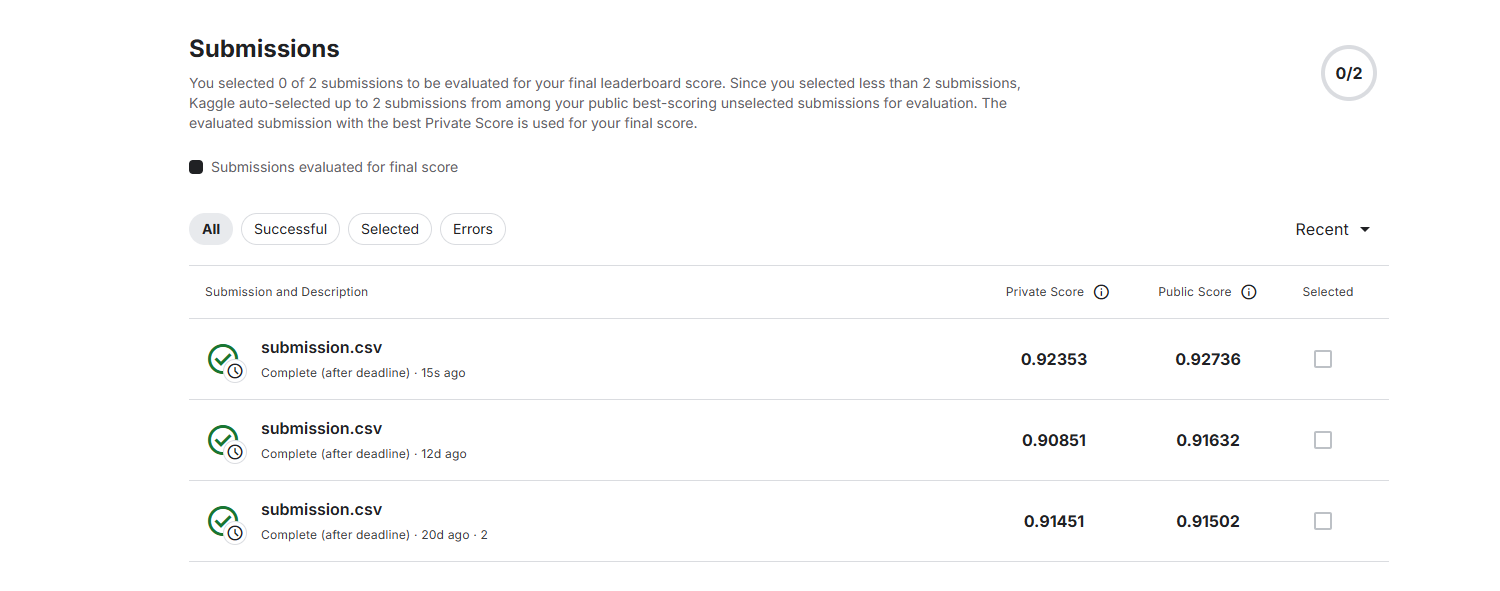